# B4 — Pre-Specified Sensitivity Analyses

Five pre-specified sensitivities, reusing the exact validated AIPW setup
from notebooks 07–08. **This notebook does not redesign the primary
analysis** — every sensitivity either reuses notebook 07's already-computed
nuisance predictions directly (Sensitivities 1, 2, 5) or refits the
identical nuisance-model specification on a different, pre-specified
population (Sensitivities 3, 4).

**Every result below is labeled `sensitivity` and reported next to
notebook 07's primary overall estimate for direct comparison. None of
these supersede the primary analysis; they test its robustness.**

**Not run here.** Written but not executed, per instruction — no commands
run, no model fit, no bootstrap performed while authoring this notebook.
Run it locally in VS Code.

**Confounder set — identical to notebook 07 (8 variables) for Sensitivities
1–3, with one deliberate exception for Sensitivity 4.** Sensitivity 4's
population is first-births-only, so `birth_order` is constant there and is
removed from that sensitivity's confounder set only (7 variables) — the
same reasoning notebook 08 already applied. Sensitivities 1, 2, and 3, and
the primary-reproduction fallback in Section 4, all use the full 8-variable
notebook-07 set unchanged.

**The five sensitivities:**
1. Propensity trimming (`0.05 <= e_hat <= 0.95`), overall population.
2. IPW-only vs. outcome-regression-only, compared against primary AIPW.
3. One birth per woman (most recent eligible birth per respondent).
4. Refined first-birth risk strata (`risk_stratum_refined_sensitivity`),
   excluding missing-complication records.
5. E-values for the primary overall Risk Ratio and its confidence bound
   closest to the null.

No additional analyses beyond these five are included.

## 1. Imports, paths, constants

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)

V2_PATH = Path("../../data/processed/df_model_v2.parquet")
PRIMARY_ROW_LEVEL_PATH = Path("../../outputs/tables/b4_aipw_row_level_nuisance.csv")
PRIMARY_SUMMARY_PATH = Path("../../outputs/tables/b4_aipw_overall_summary.csv")

OUTPUTS_DIR = Path("../../outputs")
TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"
METADATA_DIR = OUTPUTS_DIR / "metadata"
for d in (TABLES_DIR, FIGURES_DIR, METADATA_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_FOLDS = 5
CLIP_EPS = 1e-6
TRIM_LOWER = 0.05
TRIM_UPPER = 0.95
N_BOOTSTRAP = 500
BOOTSTRAP_SEED = 42
OUTCOME_MODEL_TYPE = "xgboost"  # identical to notebooks 07-08

numeric_confounders = ["birth_order", "wealth_index", "education_years"]
categorical_confounders = ["residence", "religion", "social_group", "twin_order", "state"]
confounder_cols = numeric_confounders + categorical_confounders  # identical to notebook 07, throughout this notebook

## 2. Load `df_model_v2` (read-only) and rebuild the notebook 07 population

Needed regardless of whether notebook 07's saved outputs are found, since
Sensitivities 3 and 4 require different sub-populations built from the same
source.

In [2]:
df = pd.read_parquet(V2_PATH)  # read-only
n_loaded = len(df)

EXPECTED_ROW_COUNT = 201311
assert n_loaded == EXPECTED_ROW_COUNT, (
    f"df_model_v2 row count is {n_loaded}, expected {EXPECTED_ROW_COUNT}. Stop and investigate."
)

primary_population = df[df["facility_type"].isin(["public", "private"])].copy().reset_index(drop=True)
primary_population["exposure"] = (primary_population["facility_type"] == "private").astype(int)
print(f"Notebook 07 population (public/private, all parities): {len(primary_population)}")

Notebook 07 population (public/private, all parities): 200794


## 3. Nuisance model factories and AIPW/bootstrap helpers (identical to notebooks 07–08)

In [3]:
def make_propensity_pipeline(numeric_cols, categorical_cols):
    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median", add_indicator=True)),
            ("scale", StandardScaler()),
        ]), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ])
    return Pipeline([("pre", preprocessor), ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])


def make_outcome_pipeline(numeric_cols, categorical_cols):
    outcome_numeric = numeric_cols + ["exposure"]
    if OUTCOME_MODEL_TYPE == "xgboost":
        preprocessor = ColumnTransformer([
            ("num", SimpleImputer(strategy="median", add_indicator=True), outcome_numeric),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ])
        clf = XGBClassifier(
            objective="binary:logistic", eval_metric="logloss",
            random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
            n_estimators=200, max_depth=4, learning_rate=0.05,
        )
    else:
        preprocessor = ColumnTransformer([
            ("num", Pipeline([
                ("impute", SimpleImputer(strategy="median", add_indicator=True)),
                ("scale", StandardScaler()),
            ]), outcome_numeric),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ])
        clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    return Pipeline([("pre", preprocessor), ("clf", clf)])


def run_cross_fitted_aipw(population_df, label, numeric_cols, categorical_cols):
    """Identical cross-fitting logic to notebooks 07/08, parameterized by population
    AND by confounder set -- Sensitivity 4 passes a reduced set (see Section 8);
    every other caller passes the full notebook-07 8-variable set."""
    cols = numeric_cols + categorical_cols
    W = population_df[cols].copy()
    for col in categorical_cols:
        W[col] = W[col].astype("string").fillna("Missing").astype(str)

    exposure = population_df["exposure"].to_numpy()
    outcome = population_df["csection"].astype(int).to_numpy()
    survey_weight = population_df["sample_weight_normalized"].to_numpy()
    groups = population_df["respondent_id"].to_numpy()

    n_pop = len(population_df)
    assert len(W) == n_pop, f"[{label}] Row count changed while building the confounder matrix."

    splitter = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_assignments = np.full(n_pop, -1, dtype=int)
    fold_indices = list(splitter.split(W, exposure, groups))

    for fold_id, (train_idx, test_idx) in enumerate(fold_indices):
        leak = set(groups[train_idx]) & set(groups[test_idx])
        assert not leak, f"[{label}] Fold {fold_id}: {len(leak)} respondents leaked across train/held-out."
        fold_assignments[test_idx] = fold_id
    assert (fold_assignments >= 0).all(), f"[{label}] Some rows never assigned to a held-out fold."
    covered = np.concatenate([test_idx for _, test_idx in fold_indices])
    assert len(covered) == n_pop and len(set(covered.tolist())) == n_pop, \
        f"[{label}] Row coverage across folds is not an exact one-to-one partition."

    W_with_exposure = W.copy()
    W_with_exposure["exposure"] = exposure

    e_hat = np.full(n_pop, np.nan)
    mu1_hat = np.full(n_pop, np.nan)
    mu0_hat = np.full(n_pop, np.nan)

    for fold_id, (train_idx, test_idx) in enumerate(fold_indices):
        prop_pipeline = make_propensity_pipeline(numeric_cols, categorical_cols)
        prop_pipeline.fit(W.iloc[train_idx], exposure[train_idx], clf__sample_weight=survey_weight[train_idx])
        e_hat[test_idx] = prop_pipeline.predict_proba(W.iloc[test_idx])[:, 1]

        outcome_pipeline = make_outcome_pipeline(numeric_cols, categorical_cols)
        outcome_pipeline.fit(
            W_with_exposure.iloc[train_idx], outcome[train_idx], clf__sample_weight=survey_weight[train_idx],
        )
        held_out_treated = W_with_exposure.iloc[test_idx].copy()
        held_out_treated["exposure"] = 1
        mu1_hat[test_idx] = outcome_pipeline.predict_proba(held_out_treated)[:, 1]
        held_out_control = W_with_exposure.iloc[test_idx].copy()
        held_out_control["exposure"] = 0
        mu0_hat[test_idx] = outcome_pipeline.predict_proba(held_out_control)[:, 1]

    e_hat_clipped = np.clip(e_hat, CLIP_EPS, 1 - CLIP_EPS)
    assert not np.isnan(e_hat_clipped).any() and not np.isnan(mu1_hat).any() and not np.isnan(mu0_hat).any(), \
        f"[{label}] NaN found in nuisance predictions."
    assert (e_hat_clipped > 0).all() and (e_hat_clipped < 1).all(), f"[{label}] Propensity not strictly within (0, 1)."

    print(f"[{label}] Cross-fitting complete. N={n_pop}. Confounders used: {cols}. "
          f"No fold leakage. No NaN nuisance predictions.")
    return pd.DataFrame({
        "respondent_id": population_df["respondent_id"].to_numpy(),
        "exposure": exposure, "csection": outcome,
        "sample_weight_normalized": survey_weight,
        "cluster_number": population_df["cluster_number"].to_numpy(),
        "sample_stratum_v022": population_df["sample_stratum_v022"].to_numpy(),
        "fold": fold_assignments, "e_hat_raw": e_hat, "e_hat_clipped": e_hat_clipped,
        "mu1_hat": mu1_hat, "mu0_hat": mu0_hat,
    })


def aipw_point_estimate(y, a, e, mu1, mu0, weights):
    psi1 = mu1 + (a / e) * (y - mu1)
    psi0 = mu0 + ((1 - a) / (1 - e)) * (y - mu0)
    r1 = np.average(psi1, weights=weights)
    r0 = np.average(psi0, weights=weights)
    return r1, r0, r1 - r0, r1 / r0


def ipw_only_point_estimate(y, a, e, weights):
    r1 = np.sum(weights * a * y / e) / np.sum(weights * a / e)
    r0 = np.sum(weights * (1 - a) * y / (1 - e)) / np.sum(weights * (1 - a) / (1 - e))
    return r1, r0, r1 - r0, r1 / r0


def outcome_only_point_estimate(mu1, mu0, weights):
    r1 = np.average(mu1, weights=weights)
    r0 = np.average(mu0, weights=weights)
    return r1, r0, r1 - r0, r1 / r0


def resample_indices_within_strata(psu_ids, stratum_ids, rng):
    row_positions = np.arange(len(psu_ids))
    out = []
    for s in np.unique(stratum_ids):
        stratum_mask = stratum_ids == s
        psus_in_stratum = np.unique(psu_ids[stratum_mask])
        n_psu = len(psus_in_stratum)
        drawn_psus = rng.choice(psus_in_stratum, size=n_psu, replace=True)
        for drawn_psu in drawn_psus:
            out.append(row_positions[stratum_mask & (psu_ids == drawn_psu)])
    return np.concatenate(out)


def bootstrap_ci(estimator_fn, psu_ids, stratum_ids, n_reps=N_BOOTSTRAP, seed=BOOTSTRAP_SEED):
    """Generic PSU-cluster bootstrap: estimator_fn(idx) -> (rd, rr) for a resampled index array."""
    rng = np.random.RandomState(seed)
    rd_reps = np.empty(n_reps)
    rr_reps = np.empty(n_reps)
    for b in range(n_reps):
        idx = resample_indices_within_strata(psu_ids, stratum_ids, rng)
        rd_reps[b], rr_reps[b] = estimator_fn(idx)
    return rd_reps, rr_reps


def summarize(label, r1, r0, rd, rr, rd_reps, rr_reps, n, extra=None):
    row = {
        "sensitivity": label, "n": n,
        "adjusted_private_risk_pct": r1 * 100, "adjusted_public_risk_pct": r0 * 100,
        "risk_difference_pct": rd * 100,
        "risk_difference_ci_low_pct": np.percentile(rd_reps, 2.5) * 100 if rd_reps is not None else np.nan,
        "risk_difference_ci_high_pct": np.percentile(rd_reps, 97.5) * 100 if rd_reps is not None else np.nan,
        "risk_ratio": rr,
        "risk_ratio_ci_low": np.percentile(rr_reps, 2.5) if rr_reps is not None else np.nan,
        "risk_ratio_ci_high": np.percentile(rr_reps, 97.5) if rr_reps is not None else np.nan,
    }
    if extra:
        row.update(extra)
    return row

print("Helper functions defined.")

Helper functions defined.


## 4. Load (or, if unavailable, rebuild) notebook 07's primary nuisance predictions

Sensitivities 1 and 2 reuse these directly. If notebook 07's saved output
isn't found, this falls back to refitting the identical specification here
— consistent with the load-or-refit pattern used in earlier notebooks.

In [4]:
if PRIMARY_ROW_LEVEL_PATH.exists():
    primary_row_level = pd.read_csv(PRIMARY_ROW_LEVEL_PATH)
    primary_source = f"loaded from {PRIMARY_ROW_LEVEL_PATH}"
else:
    primary_row_level = run_cross_fitted_aipw(primary_population, "primary (refit -- no saved file found)",
                                               numeric_confounders, categorical_confounders)
    primary_source = "refit in this notebook (no saved artifact found)"
print("Primary nuisance source:", primary_source)
print(f"Primary row-level frame: {primary_row_level.shape}")

if PRIMARY_SUMMARY_PATH.exists():
    primary_summary = pd.read_csv(PRIMARY_SUMMARY_PATH).iloc[0]
    print("\nLoaded primary summary from notebook 07:")
    print(primary_summary[["r1_hat_private_risk_pct", "r0_hat_public_risk_pct",
                            "risk_difference_pct", "risk_ratio"]])
else:
    # Recompute the primary point estimate from the (possibly just-refit) row-level frame
    # so a comparison baseline exists even if notebook 07's summary file is missing.
    r1_p, r0_p, rd_p, rr_p = aipw_point_estimate(
        primary_row_level["csection"].to_numpy(), primary_row_level["exposure"].to_numpy(),
        primary_row_level["e_hat_clipped"].to_numpy(), primary_row_level["mu1_hat"].to_numpy(),
        primary_row_level["mu0_hat"].to_numpy(), primary_row_level["sample_weight_normalized"].to_numpy(),
    )
    primary_summary = pd.Series({
        "r1_hat_private_risk_pct": r1_p * 100, "r0_hat_public_risk_pct": r0_p * 100,
        "risk_difference_pct": rd_p * 100, "risk_ratio": rr_p,
    })
    print("\nWARNING: notebook 07's summary CSV not found -- recomputed a primary baseline from the row-level frame instead.")
    print(primary_summary)

Primary nuisance source: loaded from ..\..\outputs\tables\b4_aipw_row_level_nuisance.csv
Primary row-level frame: (200794, 13)

Loaded primary summary from notebook 07:
r1_hat_private_risk_pct    44.964400
r0_hat_public_risk_pct     16.494602
risk_difference_pct        28.469798
risk_ratio                  2.726007
Name: 0, dtype: float64


## 5. Sensitivity 1 — Propensity trimming (`0.05 <= e_hat <= 0.95`)

Uses the primary nuisance predictions directly, restricted to the trimmed
subsample; no refitting.

In [5]:
trim_mask = primary_row_level["e_hat_clipped"].between(TRIM_LOWER, TRIM_UPPER)
trimmed = primary_row_level[trim_mask].copy()
n_dropped = len(primary_row_level) - len(trimmed)
print(f"Trimming removed {n_dropped} of {len(primary_row_level)} records "
      f"({n_dropped / len(primary_row_level) * 100:.2f}%)")

y_t = trimmed["csection"].to_numpy(); a_t = trimmed["exposure"].to_numpy()
e_t = trimmed["e_hat_clipped"].to_numpy(); mu1_t = trimmed["mu1_hat"].to_numpy(); mu0_t = trimmed["mu0_hat"].to_numpy()
w_t = trimmed["sample_weight_normalized"].to_numpy()
psu_t = trimmed["cluster_number"].to_numpy(); stratum_t = trimmed["sample_stratum_v022"].to_numpy()

r1_trim, r0_trim, rd_trim, rr_trim = aipw_point_estimate(y_t, a_t, e_t, mu1_t, mu0_t, w_t)

def trim_estimator(idx):
    _, _, rd, rr = aipw_point_estimate(y_t[idx], a_t[idx], e_t[idx], mu1_t[idx], mu0_t[idx], w_t[idx])
    return rd, rr

rd_reps_trim, rr_reps_trim = bootstrap_ci(trim_estimator, psu_t, stratum_t)
result_trim = summarize("1_propensity_trimming", r1_trim, r0_trim, rd_trim, rr_trim,
                         rd_reps_trim, rr_reps_trim, len(trimmed), extra={"n_dropped_by_trimming": n_dropped})
print(result_trim)

Trimming removed 17501 of 200794 records (8.72%)
{'sensitivity': '1_propensity_trimming', 'n': 183293, 'adjusted_private_risk_pct': np.float64(45.51527091054021), 'adjusted_public_risk_pct': np.float64(16.953995213503006), 'risk_difference_pct': np.float64(28.561275697037203), 'risk_difference_ci_low_pct': np.float64(27.775893279584597), 'risk_difference_ci_high_pct': np.float64(29.290943717150807), 'risk_ratio': np.float64(2.6846339365655583), 'risk_ratio_ci_low': np.float64(2.6160373009958358), 'risk_ratio_ci_high': np.float64(2.757311553756474), 'n_dropped_by_trimming': 17501}


## 6. Sensitivity 2 — IPW-only vs. outcome-regression-only vs. primary AIPW

Same primary nuisance predictions, untrimmed, full population. A large
divergence between the IPW-only and outcome-only estimates is itself a
useful double-robustness diagnostic: AIPW is protected if *either* nuisance
model is correctly specified, but a big gap here suggests at least one of
them may not be.

In [7]:
y_p = primary_row_level["csection"].to_numpy(); a_p = primary_row_level["exposure"].to_numpy()
e_p = primary_row_level["e_hat_clipped"].to_numpy(); mu1_p = primary_row_level["mu1_hat"].to_numpy()
mu0_p = primary_row_level["mu0_hat"].to_numpy(); w_p = primary_row_level["sample_weight_normalized"].to_numpy()
psu_p = primary_row_level["cluster_number"].to_numpy(); stratum_p = primary_row_level["sample_stratum_v022"].to_numpy()

r1_ipw, r0_ipw, rd_ipw, rr_ipw = ipw_only_point_estimate(y_p, a_p, e_p, w_p)
r1_reg, r0_reg, rd_reg, rr_reg = outcome_only_point_estimate(mu1_p, mu0_p, w_p)

# Single bootstrap loop: draw one PSU-stratified resample per replicate and compute
# BOTH the IPW-only and outcome-only RD/RR from that same resampled index, instead of
# resampling twice (once per estimator) as in the original version. Same seed, same
# number of replicates, same resampling logic, same estimators -- runtime only.
rng = np.random.RandomState(BOOTSTRAP_SEED)
rd_reps_ipw = np.empty(N_BOOTSTRAP)
rr_reps_ipw = np.empty(N_BOOTSTRAP)
rd_reps_reg = np.empty(N_BOOTSTRAP)
rr_reps_reg = np.empty(N_BOOTSTRAP)

for b in range(N_BOOTSTRAP):
    idx = resample_indices_within_strata(psu_p, stratum_p, rng)
    _, _, rd_reps_ipw[b], rr_reps_ipw[b] = ipw_only_point_estimate(y_p[idx], a_p[idx], e_p[idx], w_p[idx])
    _, _, rd_reps_reg[b], rr_reps_reg[b] = outcome_only_point_estimate(mu1_p[idx], mu0_p[idx], w_p[idx])
    if (b + 1) % 50 == 0:
        print(f"  Sensitivity 2 bootstrap: {b + 1}/{N_BOOTSTRAP} replicates complete")

result_ipw = summarize("2a_ipw_only", r1_ipw, r0_ipw, rd_ipw, rr_ipw, rd_reps_ipw, rr_reps_ipw, len(primary_row_level))
result_reg = summarize("2b_outcome_regression_only", r1_reg, r0_reg, rd_reg, rr_reg,
                        rd_reps_reg, rr_reps_reg, len(primary_row_level))

print(result_ipw)
print(result_reg)
print(f"\nDivergence check -- AIPW RD: {primary_summary['risk_difference_pct']:.2f} pts | "
      f"IPW-only RD: {rd_ipw*100:.2f} pts | Outcome-only RD: {rd_reg*100:.2f} pts")

  Sensitivity 2 bootstrap: 50/500 replicates complete
  Sensitivity 2 bootstrap: 100/500 replicates complete
  Sensitivity 2 bootstrap: 150/500 replicates complete
  Sensitivity 2 bootstrap: 200/500 replicates complete
  Sensitivity 2 bootstrap: 250/500 replicates complete
  Sensitivity 2 bootstrap: 300/500 replicates complete
  Sensitivity 2 bootstrap: 350/500 replicates complete
  Sensitivity 2 bootstrap: 400/500 replicates complete
  Sensitivity 2 bootstrap: 450/500 replicates complete
  Sensitivity 2 bootstrap: 500/500 replicates complete
{'sensitivity': '2a_ipw_only', 'n': 200794, 'adjusted_private_risk_pct': np.float64(44.30488382061436), 'adjusted_public_risk_pct': np.float64(16.323062985390973), 'risk_difference_pct': np.float64(27.981820835223388), 'risk_difference_ci_low_pct': np.float64(27.0852532273776), 'risk_difference_ci_high_pct': np.float64(28.825381717600656), 'risk_ratio': np.float64(2.7142506195232428), 'risk_ratio_ci_low': np.float64(2.6337041721619214), 'risk_rati

## 7. Sensitivity 3 — One birth per woman (most recent eligible birth)

Keeps only, for each `respondent_id`, the row with the maximum
`birth_index` within the public/private analytic population — i.e. her
single most recent eligible birth. Requires refitting (different
population), respondent-grouped as always (though with exactly one row per
respondent the grouping no longer changes fold assignment behavior, it is
kept for consistency with every other cross-fitting step in this
project).

In [8]:
idx_of_most_recent = primary_population.groupby("respondent_id")["birth_index"].idxmax()
one_birth_population = primary_population.loc[idx_of_most_recent].copy().reset_index(drop=True)

assert one_birth_population["respondent_id"].duplicated().sum() == 0, \
    "One-birth-per-woman population still contains duplicate respondents."
print(f"One-birth-per-woman population: {len(one_birth_population)} "
      f"(from {len(primary_population)} total records, {primary_population['respondent_id'].nunique()} respondents)")

one_birth_nuisance = run_cross_fitted_aipw(one_birth_population, "3_one_birth_per_woman",
                                            numeric_confounders, categorical_confounders)

y_1 = one_birth_nuisance["csection"].to_numpy(); a_1 = one_birth_nuisance["exposure"].to_numpy()
e_1 = one_birth_nuisance["e_hat_clipped"].to_numpy(); mu1_1 = one_birth_nuisance["mu1_hat"].to_numpy()
mu0_1 = one_birth_nuisance["mu0_hat"].to_numpy(); w_1 = one_birth_nuisance["sample_weight_normalized"].to_numpy()
psu_1 = one_birth_nuisance["cluster_number"].to_numpy(); stratum_1 = one_birth_nuisance["sample_stratum_v022"].to_numpy()

r1_1b, r0_1b, rd_1b, rr_1b = aipw_point_estimate(y_1, a_1, e_1, mu1_1, mu0_1, w_1)

def one_birth_estimator(idx):
    _, _, rd, rr = aipw_point_estimate(y_1[idx], a_1[idx], e_1[idx], mu1_1[idx], mu0_1[idx], w_1[idx])
    return rd, rr

rd_reps_1b, rr_reps_1b = bootstrap_ci(one_birth_estimator, psu_1, stratum_1)
result_one_birth = summarize("3_one_birth_per_woman", r1_1b, r0_1b, rd_1b, rr_1b,
                              rd_reps_1b, rr_reps_1b, len(one_birth_population))
print(result_one_birth)

One-birth-per-woman population: 158092 (from 200794 total records, 158092 respondents)
[3_one_birth_per_woman] Cross-fitting complete. N=158092. Confounders used: ['birth_order', 'wealth_index', 'education_years', 'residence', 'religion', 'social_group', 'twin_order', 'state']. No fold leakage. No NaN nuisance predictions.
{'sensitivity': '3_one_birth_per_woman', 'n': 158092, 'adjusted_private_risk_pct': np.float64(46.18289074027866), 'adjusted_public_risk_pct': np.float64(17.432532321046367), 'risk_difference_pct': np.float64(28.750358419232292), 'risk_difference_ci_low_pct': np.float64(27.96014391842634), 'risk_difference_ci_high_pct': np.float64(29.586816130212483), 'risk_ratio': np.float64(2.6492359164894173), 'risk_ratio_ci_low': np.float64(2.5786053425863615), 'risk_ratio_ci_high': np.float64(2.72504190211164)}


## 8. Sensitivity 4 — Refined first-birth risk strata

Population: `risk_stratum_refined_sensitivity` in
`{refined_lower_risk, refined_elevated_risk}` (already excludes missing-
complication and multiparous records by construction), public/private
only. Refits independently per refined stratum, same pattern as
notebook 08.

**Confounder set for this sensitivity only: `birth_order` removed.**
Every record in this population is a first birth (`birth_order == 1` by
construction), so it is constant and non-informative here — exactly the
same reasoning notebook 08 used to drop it. Sensitivities 1–3 above keep
the full 8-variable notebook-07 set unchanged; this 7-variable set applies
**only** to Sensitivity 4.

In [9]:
numeric_confounders_s4 = ["wealth_index", "education_years"]  # birth_order removed -- constant in this population
categorical_confounders_s4 = categorical_confounders  # unchanged: residence, religion, social_group, twin_order, state
confounder_cols_s4 = numeric_confounders_s4 + categorical_confounders_s4

assert "birth_order" not in confounder_cols_s4, "birth_order should not be present in the Sensitivity 4 confounder set."
print(f"Sensitivity 4 confounder set: {len(confounder_cols_s4)} variables (birth_order excluded). "
      f"Sensitivities 1-3 continue to use the full {len(confounder_cols)}-variable notebook-07 set.")

refined_strata = ["refined_lower_risk", "refined_elevated_risk"]
in_refined = df["risk_stratum_refined_sensitivity"].isin(refined_strata)
in_facility = df["facility_type"].isin(["public", "private"])
refined_population = df[in_refined & in_facility].copy().reset_index(drop=True)
refined_population["exposure"] = (refined_population["facility_type"] == "private").astype(int)

assert set(refined_population["risk_stratum_refined_sensitivity"].unique()) <= set(refined_strata)
print(f"Refined-strata population: {len(refined_population)}")
print(refined_population.groupby(["risk_stratum_refined_sensitivity", "facility_type"]).size())

refined_results = {}
for stratum in refined_strata:
    stratum_df = refined_population[refined_population["risk_stratum_refined_sensitivity"] == stratum].copy()
    nuisance = run_cross_fitted_aipw(stratum_df, f"4_{stratum}", numeric_confounders_s4, categorical_confounders_s4)

    y_r = nuisance["csection"].to_numpy(); a_r = nuisance["exposure"].to_numpy()
    e_r = nuisance["e_hat_clipped"].to_numpy(); mu1_r = nuisance["mu1_hat"].to_numpy(); mu0_r = nuisance["mu0_hat"].to_numpy()
    w_r = nuisance["sample_weight_normalized"].to_numpy()
    psu_r = nuisance["cluster_number"].to_numpy(); stratum_design = nuisance["sample_stratum_v022"].to_numpy()

    r1_s, r0_s, rd_s, rr_s = aipw_point_estimate(y_r, a_r, e_r, mu1_r, mu0_r, w_r)

    def make_estimator(y_arr, a_arr, e_arr, mu1_arr, mu0_arr, w_arr):
        def estimator(idx):
            _, _, rd, rr = aipw_point_estimate(y_arr[idx], a_arr[idx], e_arr[idx], mu1_arr[idx], mu0_arr[idx], w_arr[idx])
            return rd, rr
        return estimator

    rd_reps_s, rr_reps_s = bootstrap_ci(make_estimator(y_r, a_r, e_r, mu1_r, mu0_r, w_r), psu_r, stratum_design)
    refined_results[stratum] = summarize(f"4_{stratum}", r1_s, r0_s, rd_s, rr_s, rd_reps_s, rr_reps_s, len(stratum_df))
    print(refined_results[stratum])

Sensitivity 4 confounder set: 7 variables (birth_order excluded). Sensitivities 1-3 continue to use the full 8-variable notebook-07 set.
Refined-strata population: 59208
risk_stratum_refined_sensitivity  facility_type
refined_elevated_risk             private           7911
                                  public           16483
refined_lower_risk                private           9874
                                  public           24940
dtype: int64
[4_refined_lower_risk] Cross-fitting complete. N=34814. Confounders used: ['wealth_index', 'education_years', 'residence', 'religion', 'social_group', 'twin_order', 'state']. No fold leakage. No NaN nuisance predictions.
{'sensitivity': '4_refined_lower_risk', 'n': 34814, 'adjusted_private_risk_pct': np.float64(51.13559335152296), 'adjusted_public_risk_pct': np.float64(19.80975017181269), 'risk_difference_pct': np.float64(31.325843179710265), 'risk_difference_ci_low_pct': np.float64(29.902879662846026), 'risk_difference_ci_high_pct': n

## 9. Sensitivity 5 — E-values for the primary overall Risk Ratio

Standard E-value formula: for `RR >= 1`, `E = RR + sqrt(RR * (RR - 1))`;
for `RR < 1`, first invert (`RR' = 1/RR`) and apply the same formula.
Computed for the primary point RR and for whichever confidence bound is
closer to the null value (1), per standard E-value reporting practice.

In [10]:
def e_value(rr):
    if rr < 1:
        rr = 1 / rr
    return rr + np.sqrt(rr * (rr - 1))


primary_rr = primary_summary["risk_ratio"] if "risk_ratio" in primary_summary else None
if primary_rr is None:
    # primary_summary loaded from CSV uses this column name; the recomputed fallback series does too.
    raise KeyError("Expected a 'risk_ratio' entry in primary_summary.")

# Confidence bound closest to the null (1) -- read from notebook 07's saved summary if available.
if PRIMARY_SUMMARY_PATH.exists():
    ci_low = float(pd.read_csv(PRIMARY_SUMMARY_PATH).iloc[0]["risk_ratio_ci_low"])
    ci_high = float(pd.read_csv(PRIMARY_SUMMARY_PATH).iloc[0]["risk_ratio_ci_high"])
else:
    print("WARNING: notebook 07's summary CSV not found -- cannot compute the CI-bound E-value; "
          "only the point-estimate E-value will be reported.")
    ci_low = ci_high = None

point_e_value = e_value(primary_rr)
print(f"Primary RR: {primary_rr:.3f} -> E-value (point estimate): {point_e_value:.3f}")

if ci_low is not None:
    bound_closer_to_null = ci_low if abs(ci_low - 1) < abs(ci_high - 1) else ci_high
    if (bound_closer_to_null - 1) * (primary_rr - 1) < 0:
        print("NOTE: the confidence interval crosses the null (RR = 1); the E-value for a CI bound "
              "on the opposite side of 1 from the point estimate is conventionally reported as 1 "
              "(no confounding needed to shift that bound to the null).")
        bound_e_value = 1.0
    else:
        bound_e_value = e_value(bound_closer_to_null)
    print(f"CI bound closest to the null: {bound_closer_to_null:.3f} -> E-value: {bound_e_value:.3f}")
else:
    bound_e_value = np.nan
    bound_closer_to_null = np.nan

e_value_results = pd.DataFrame([{
    "sensitivity": "5_e_value_point_estimate", "rr_input": primary_rr, "e_value": point_e_value,
}, {
    "sensitivity": "5_e_value_ci_bound_closest_to_null", "rr_input": bound_closer_to_null, "e_value": bound_e_value,
}])
e_value_results

Primary RR: 2.726 -> E-value (point estimate): 4.895
CI bound closest to the null: 2.657 -> E-value: 4.754


,sensitivity,rr_input,e_value
0,5_e_value_point_estimate,2.726007,4.895133
1,5_e_value_ci_bound_closest_to_null,2.656604,4.754446


## 10. Consolidated sensitivity-results CSV and supporting diagnostics

In [11]:
all_results = pd.DataFrame([
    result_trim, result_ipw, result_reg, result_one_birth,
    refined_results["refined_lower_risk"], refined_results["refined_elevated_risk"],
])

# Attach the primary estimate as a reference row and compute deltas against it for easy comparison.
primary_reference = {
    "sensitivity": "0_primary_AIPW_notebook07_REFERENCE",
    "n": len(primary_row_level),
    "adjusted_private_risk_pct": primary_summary["r1_hat_private_risk_pct"],
    "adjusted_public_risk_pct": primary_summary["r0_hat_public_risk_pct"],
    "risk_difference_pct": primary_summary["risk_difference_pct"],
    "risk_difference_ci_low_pct": primary_summary.get("risk_difference_ci_low_pct", np.nan),
    "risk_difference_ci_high_pct": primary_summary.get("risk_difference_ci_high_pct", np.nan),
    "risk_ratio": primary_summary["risk_ratio"],
    "risk_ratio_ci_low": primary_summary.get("risk_ratio_ci_low", np.nan),
    "risk_ratio_ci_high": primary_summary.get("risk_ratio_ci_high", np.nan),
}
all_results = pd.concat([pd.DataFrame([primary_reference]), all_results], ignore_index=True)

all_results["rd_delta_vs_primary_pct"] = all_results["risk_difference_pct"] - primary_reference["risk_difference_pct"]
all_results["rr_delta_vs_primary"] = all_results["risk_ratio"] - primary_reference["risk_ratio"]

# Append the E-value rows (different schema -- NaN for RD/RR columns, filled for their own columns).
e_value_rows = e_value_results.copy()
for col in all_results.columns:
    if col not in e_value_rows.columns:
        e_value_rows[col] = np.nan
all_results = pd.concat([all_results, e_value_rows[all_results.columns]], ignore_index=True)

all_results.to_csv(TABLES_DIR / "b4_sensitivity_results_consolidated.csv", index=False)
print(f"Saved consolidated sensitivity results: {all_results.shape}")
all_results

Saved consolidated sensitivity results: (9, 13)


,sensitivity,n,adjusted_private_risk_pct,adjusted_public_risk_pct,risk_difference_pct,risk_difference_ci_low_pct,risk_difference_ci_high_pct,risk_ratio,risk_ratio_ci_low,risk_ratio_ci_high,n_dropped_by_trimming,rd_delta_vs_primary_pct,rr_delta_vs_primary
0,0_primary_AIPW_notebook07_REFERENCE,200794.0,44.964400,16.494602,28.469798,27.671957,29.244259,2.726007,2.656604,2.803453,NaN,0.000000,0.000000
1,1_propensity_trimming,183293.0,45.515271,16.953995,28.561276,27.775893,29.290944,2.684634,2.616037,2.757312,17501.0,0.091477,-0.041373
2,2a_ipw_only,200794.0,44.304884,16.323063,27.981821,27.085253,28.825382,2.714251,2.633704,2.796270,NaN,-0.487978,-0.011756
3,2b_outcome_regression_only,200794.0,43.915158,16.408727,27.506432,27.420222,27.608112,2.676329,2.664060,2.688777,NaN,-0.963367,-0.049678
4,3_one_birth_per_woman,158092.0,46.182891,17.432532,28.750358,27.960144,29.586816,2.649236,2.578605,2.725042,NaN,0.280560,-0.076771
5,4_refined_lower_risk,34814.0,51.135593,19.809750,31.325843,29.902880,32.731888,2.581335,2.473059,2.711102,NaN,2.856045,-0.144672
6,4_refined_elevated_risk,24394.0,57.999437,26.947880,31.051557,29.048395,33.366465,2.152282,2.054447,2.270003,NaN,2.581758,-0.573725
7,5_e_value_point_estimate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,5_e_value_ci_bound_closest_to_null,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Supporting diagnostics
trimming_diagnostics = pd.DataFrame([{
    "n_before_trimming": len(primary_row_level), "n_after_trimming": len(trimmed), "n_dropped": n_dropped,
    "pct_dropped": round(n_dropped / len(primary_row_level) * 100, 2),
}])
trimming_diagnostics.to_csv(TABLES_DIR / "b4_sensitivity_trimming_diagnostics.csv", index=False)

one_birth_diagnostics = pd.DataFrame([{
    "n_full_population": len(primary_population), "n_one_birth_population": len(one_birth_population),
    "n_respondents": one_birth_population["respondent_id"].nunique(),
}])
one_birth_diagnostics.to_csv(TABLES_DIR / "b4_sensitivity_one_birth_diagnostics.csv", index=False)

refined_population_diagnostics = refined_population.groupby(
    ["risk_stratum_refined_sensitivity", "facility_type"]
).size().reset_index(name="n")
refined_population_diagnostics.to_csv(TABLES_DIR / "b4_sensitivity_refined_population_diagnostics.csv", index=False)

print("Saved supporting diagnostic CSVs.")

Saved supporting diagnostic CSVs.


## 11. Comparison forest plot — all sensitivities vs. the primary estimate

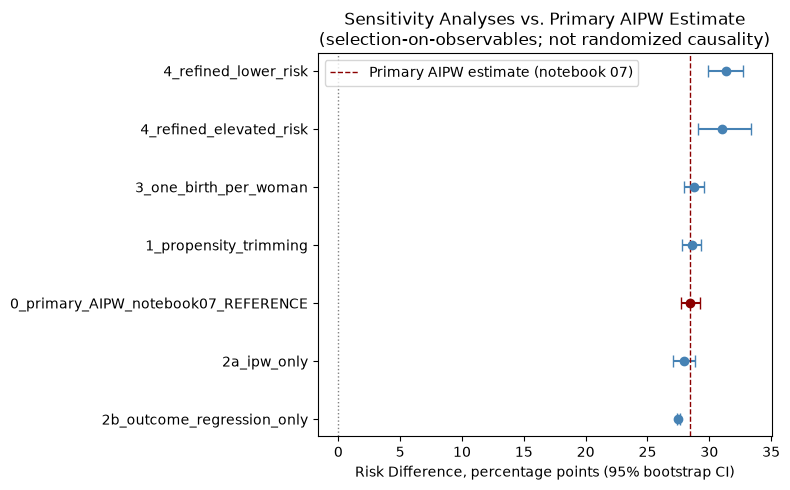

Saved: ..\..\outputs\figures\b4_sensitivity_comparison_forest_plot.png


In [13]:
plot_data = all_results[~all_results["sensitivity"].str.startswith("5_e_value")].copy()
plot_data = plot_data.sort_values("risk_difference_pct")

fig, ax = plt.subplots(figsize=(8, max(5, len(plot_data) * 0.5)))
y_pos = np.arange(len(plot_data))
is_primary = plot_data["sensitivity"].str.startswith("0_primary")
colors = ["darkred" if p else "steelblue" for p in is_primary]

err_low = plot_data["risk_difference_pct"] - plot_data["risk_difference_ci_low_pct"]
err_high = plot_data["risk_difference_ci_high_pct"] - plot_data["risk_difference_pct"]

for i, (y, row, color) in enumerate(zip(y_pos, plot_data.itertuples(), colors)):
    ax.errorbar(row.risk_difference_pct, y, xerr=[[err_low.iloc[i]], [err_high.iloc[i]]],
                fmt="o", capsize=4, color=color)

ax.axvline(primary_reference["risk_difference_pct"], color="darkred", linestyle="--", linewidth=1,
           label="Primary AIPW estimate (notebook 07)")
ax.axvline(0, color="gray", linestyle=":", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_data["sensitivity"])
ax.set_xlabel("Risk Difference, percentage points (95% bootstrap CI)")
ax.set_title("Sensitivity Analyses vs. Primary AIPW Estimate\n(selection-on-observables; not randomized causality)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "b4_sensitivity_comparison_forest_plot.png", dpi=200)
plt.show()
print("Saved:", FIGURES_DIR / "b4_sensitivity_comparison_forest_plot.png")

## 12. Save metadata

In [14]:
metadata = {
    "random_state": RANDOM_STATE,
    "primary_nuisance_source": primary_source,
    "confounder_set": {
        "sensitivities_1_2_3_and_primary_fallback": confounder_cols,
        "sensitivity_4_refined_strata": confounder_cols_s4,
        "sensitivity_4_note": "birth_order removed relative to the notebook-07 set -- constant in a first-births-only population",
    },
    "sensitivities_run": [
        "1_propensity_trimming (0.05-0.95, reuses primary nuisance predictions)",
        "2a_ipw_only / 2b_outcome_regression_only (reuse primary nuisance predictions)",
        "3_one_birth_per_woman (refit on most-recent-eligible-birth-per-respondent population)",
        "4_refined_lower_risk / 4_refined_elevated_risk (refit on risk_stratum_refined_sensitivity population)",
        "5_e_value_point_estimate / 5_e_value_ci_bound_closest_to_null (closed-form, no refitting)",
    ],
    "no_additional_analyses_added": True,
    "bootstrap": {
        "method": "PSU-cluster bootstrap, resampled with replacement within sample_stratum_v022 strata "
                   "(within each sensitivity's own population)",
        "n_replicates": N_BOOTSTRAP,
        "seed": BOOTSTRAP_SEED,
        "ci_method": "percentile (2.5 / 97.5)",
        "caveat": "Nuisance predictions are fixed/plugged-in per replicate for sensitivities that reuse "
                   "primary predictions (1, 2); sensitivities requiring refitting (3, 4) still treat their "
                   "OWN nuisance predictions as fixed across bootstrap replicates -- no sensitivity refits "
                   "nuisance models inside the bootstrap loop itself.",
    },
    "interpretation_rule": (
        "Every result in this notebook is a SENSITIVITY analysis, reported next to (never replacing) "
        "the primary AIPW estimate from notebook 07. Selection-on-observables causal-style estimates "
        "throughout, not randomized causality."
    ),
}

with open(METADATA_DIR / "b4_sensitivity_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

print("Saved:", METADATA_DIR / "b4_sensitivity_metadata.json")

Saved: ..\..\outputs\metadata\b4_sensitivity_metadata.json
